### Set Up

In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Base Columns

    changeset_id - ID of the changeset
    edit_count - Number of edits in the changeset
    user_name - OSM contributor username
    year - Year of the changeset
    month - Month of the changeset

Enriched Columns (added by scripts/changeset_raw_data_to_data.py)

    created_by - Normalized editing software name
    device_type - Classification: desktop_editor, mobile_editor, tool, other
    bot - Boolean indicating if the changeset was made by a bot
    mid_pos_x, mid_pos_y - Discretized coordinates (0-360, 0-180)
    imagery_used - Array of imagery sources used
    hashtags - Array of hashtags from the changeset
    source - Array of data sources used
    mobile_os - Mobile OS detection (Android, iOS, or NULL)
    streetcomplete_quest - Normalized StreetComplete quest type
    all_tags - Array of all tag prefixes used
    organised_team - Organised team/corporation affiliation if applicable
    for_profit - Boolean indicating if the changeset was made by a for-profit organisation

In [9]:
data = "/data/input/piebro/changeset_data/year=*/month=*/*.parquet"
db = duckdb.read_parquet(r"data/input/piebro/changeset_data/year=*/month=*/*.parquet", hive_partitioning=1) 

In [10]:
df_total = duckdb.sql("""
    SELECT 
        CONCAT(year, '-', LPAD(CAST(month as VARCHAR), 2, '0')) as months,
        COUNT(DISTINCT user_name) as Contributors,
        CAST(SUM(edit_count) as BIGINT) as Edits,
        CAST(COUNT(*) AS INTEGER) as Changesets
    FROM db
    GROUP BY months

    
""").df()
df_total= df_total.sort_values(by='months')

In [11]:
df_total = df_total[df_total["months"] >= "2019-06"]

In [5]:
from matplotlib.ticker import FuncFormatter
def millions(x, pos):
    'The two args are the value and tick position'
    return '%1.f million' % (x * 1e-6)


formatter = FuncFormatter(millions)
plain_formatter = FuncFormatter(lambda x, _: f"{int(x):,}")

## Rapid and microsoft / google buildings imports

In [6]:
df_new = duckdb.sql("""
    SELECT 
        CONCAT(year, '-', LPAD(CAST(month as VARCHAR), 2, '0')) as months,
        year,
        COUNT(DISTINCT user_name) as Contributors,
        CAST(SUM(edit_count) as BIGINT) as Edits,
        CAST(COUNT(*) AS INTEGER) as Changesets
    FROM db
    WHERE (
        created_by = 'Rapid' 
        OR array_to_string(source, ',') ILIKE '%microsoft/BuildingFootprints%'
        OR array_to_string(source, ',') ILIKE '%mapwithai%'
        OR array_to_string(source, ',') ILIKE '%esri/Google_Africa_Buildings%'
        OR array_to_string(source, ',') ILIKE '%esri/Google_Open_Buildings%'
        OR array_to_string(hashtags, ',') ILIKE '%mapwithai%'
        ) 
    GROUP BY months, year  
    ORDER BY months, year DESC
""").df()


RuntimeError: Query interrupted

In [10]:
df_new.to_csv("../data/ouput/v2/monthly_ai_stats.csv")

In [2]:
df_new = pd.read_csv("../data/ouput/v2/monthly_ai_stats.csv").drop(columns={"Unnamed: 0"})

In [3]:
df_new = df_new[df_new["months"] >= "2019-06"]
df_new['months_dt'] = pd.to_datetime(df_new['months'])

In [4]:
df_new = df_new.rename(columns={"Edits":"EditsR","Changesets":"ChangesetsR","Contributors": "ContributorsR"  })

In [12]:
df_new_p = pd.merge(df_new, df_total, how='left', on='months' )

df_new_p['editsPerc'] = (df_new_p['EditsR']/df_new_p['Edits'])*100
df_new_p['changesetsPerc'] = (df_new_p['ChangesetsR']/df_new_p['Changesets'])*100
df_new_p['contributorsPerc'] = (df_new_p['ContributorsR']/df_new_p['Contributors'])*100

In [13]:
df_new_p = df_new_p[(df_new_p["months"] >= "2020-01") & (df_new_p["months"] <= "2025-12")]

In [23]:
yearly = df_new_p.drop(columns={"months", "months_dt"}).groupby("year").sum()

In [26]:
yearly

,ContributorsR,EditsR,ChangesetsR,Contributors,Edits,Changesets,editsPerc,changesetsPerc,contributorsPerc
year,,,,,,,,,
2020,10103,93841411,1108743,574738,1559317238,17685355,71.611253,74.741809,21.030504
2021,7277,124449939,988697,596384,1539650563,18876002,97.503831,61.733572,14.534943
2022,5949,113019281,590910,544097,1287510669,15116259,105.218130,47.204201,13.091163
2023,13884,98608049,428046,576583,1329787198,15019265,89.183593,34.313059,28.666637
2024,8293,73820071,302605,568303,1295927701,15113717,68.726776,24.169673,17.690451
2025,8963,56310820,322765,597439,1282164582,15856773,52.647791,24.499285,18.261755


In [27]:
(322765/15856773)*100

2.035502431673834

In [28]:
(56310820/1282164582)*100

4.391855834308173

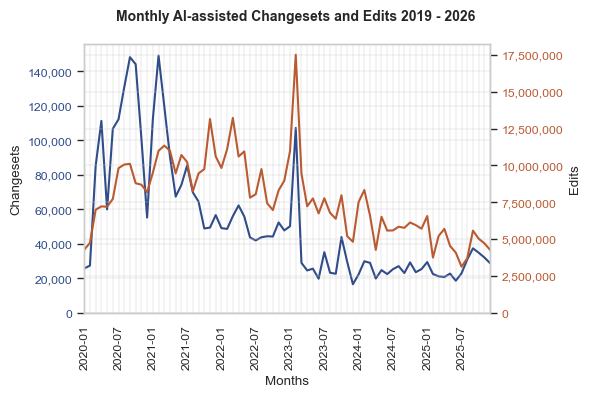

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.set_theme(style="whitegrid")
sns.set_context("paper")
fig.suptitle("Monthly AI-assisted Changesets and Edits 2019 - 2026", fontsize=10, fontweight="bold")

sns.lineplot(x = 'months',
         y='ChangesetsR',
         data=df_new_p,
         linewidth=1.5,
            color = "#304C89")
ax.yaxis.set_major_formatter(plain_formatter)
ax.tick_params(axis='y', labelcolor="#304C89")


ax.xaxis.set_tick_params(rotation=90)
ax.set_xlabel('Months')
ax.set_ylabel('Changesets')
ax.set_ylim(0,)
ax.set_xlim("2020-01","2025-12")
ax.grid(linewidth=0.3)


ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(plain_formatter)
ax2.tick_params(axis='y', labelcolor="#BA5A31")
sns.lineplot(x = 'months',
             y='EditsR',
             data=df_new_p,
             linewidth=1.5,
            ax = ax2,
             color = "#BA5A31"
            )
ax2.set_ylabel('Edits')
ax2.set_ylim(0,)
ax2.set_xlim("2020-01","2025-12")
ax2.grid(linewidth=0.3)

# Hide every second x-axis tick label
for i, label in enumerate(ax.get_xticklabels()):
    if i % 6 != 0:
        label.set_visible(False)
        
fig.tight_layout()
#fig.savefig("../results/AI_edits_changesets_20_26_v2.png", bbox_inches="tight")
plt.show()

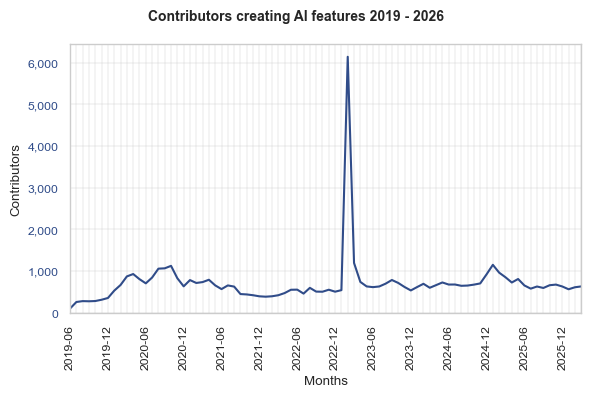

In [34]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.set_theme(style="whitegrid")
sns.set_context("paper")
fig.suptitle("Contributors creating AI features 2019 - 2026", fontsize=10, fontweight="bold")

sns.lineplot(x = 'months',
         y='ContributorsR',
         data=df_new,
         linewidth=1.5,
            color = "#304C89")
ax.yaxis.set_major_formatter(plain_formatter)
ax.tick_params(axis='y', labelcolor="#304C89")
ax.set_ylabel('Contributors')
ax.set_ylim(0,)
ax.set_xlim("2019-06","2026-03")
ax.grid(linewidth=0.3)


ax.xaxis.set_tick_params(rotation=90)
ax.set_xlabel('Months')


# Hide every second x-axis tick label
for i, label in enumerate(ax.get_xticklabels()):
    if i % 6 != 0:
        label.set_visible(False)
        
fig.tight_layout()
fig.savefig("../results/AI20_26_contributors_v2.png", bbox_inches="tight")
plt.show()

In [12]:
from matplotlib.ticker import AutoMinorLocator, MultipleLocator


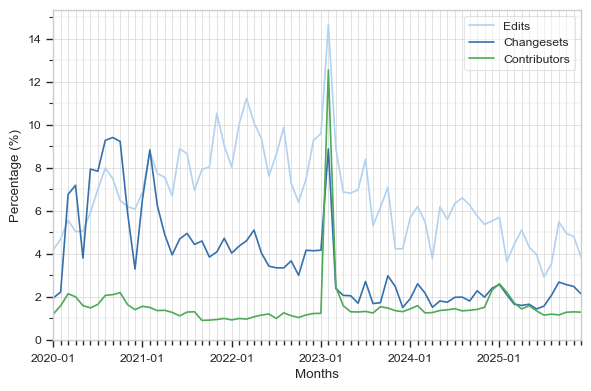

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper")

#fig.suptitle("AI% of Total 2019 - 2026", fontsize=10, fontweight="bold", y=0.94)

def show_every_nth_ticklabel(ax, n=12, long_len=20, short_len=3.5, pad=5):
    for i, tick in enumerate(ax.xaxis.get_major_ticks()):
        show = (i % n == 0)
        tick.label1.set_visible(show)
        tick.tick1line.set_visible(True)
        tick.tick1line.set_markersize(long_len if show else short_len)
        if show:
            tick.set_pad(pad)
            
sns.lineplot(x = 'months',
         y='editsPerc',
         data=df_new_p,
         linewidth=1.2,
         color = "#B1D2F1",
         label = 'Edits')
#ax.yaxis.set_major_formatter(plain_formatter)


#ax.xaxis.set_tick_params(rotation=90)
ax.set_xlabel('Months')

sns.lineplot(x = 'months',
             y='changesetsPerc',
             data=df_new_p,
             linewidth=1.2,
             color = "#3670AB",
             label = "Changesets"
            )

sns.lineplot(x = 'months',
             y='contributorsPerc',
             data=df_new_p,
             linewidth=1.2,
             color = "#4DAA57",
             label = "Contributors"
            )

ax.set_ylabel("Percentage (%)")
ax.set_xlim('2020-01', '2025-12')
ax.set_ylim(0, )

#ax.grid(linewidth=0.4)

ax.yaxis.set_minor_locator(AutoMinorLocator(2))  
ax.grid(which='major', linewidth=0.4)
ax.grid(which='minor', linewidth=0.2, )  
show_every_nth_ticklabel(ax)

ax.legend(loc="upper right", frameon=True, facecolor="w", framealpha = 0.5)

        
fig.tight_layout()
fig.savefig("../results/AI_percentage20_25_v4.png", bbox_inches="tight", dpi=300)
plt.show()

In [56]:
df_new_p.sort_values(by = "changesetsPerc")

,months,year,ContributorsR,EditsR,ChangesetsR,months_dt,Contributors,Edits,Changesets,editsPerc,changesetsPerc,contributorsPerc
72,2025-06,2025,658,4084116,18675,2025-06-01,48877,103125840,1301389,3.960323,1.435005,1.346236
54,2023-12,2023,539,4821426,16618,2023-12-01,41153,114000520,1105635,4.229302,1.503028,1.309747
58,2024-04,2024,666,4273543,19954,2024-04-01,52544,113321310,1319674,3.771173,1.512040,1.267509
73,2025-07,2025,582,3133379,22966,2025-07-01,50716,107326349,1464216,2.919487,1.568484,1.147567
70,2025-04,2025,729,5697276,20860,2025-04-01,50750,111628174,1303459,5.103798,1.600357,1.436453
...,...,...,...,...,...,...,...,...,...,...,...,...
20,2021-02,2021,718,10992747,149179,2021-02-01,47684,126101972,1690335,8.717347,8.825410,1.505746
44,2023-02,2023,6140,17502561,107225,2023-02-01,48967,119491322,1208846,14.647558,8.870030,12.539057
16,2020-10,2020,1128,8791780,144185,2020-10-01,51444,135609611,1564160,6.483154,9.218047,2.192676
14,2020-08,2020,1061,10061047,130830,2020-08-01,51392,126011319,1411640,7.984241,9.267944,2.064524
